<center><h1>MINI PROJECT</h1></center>

<center><h1>CLASSIFICATION BETWEEN MULTIPLE SCLEROSIS AND CEREBRAL SMALL VESSEL DIESEASE</h1</center>

<h1>Step 1: Load and Preprocess MRI Scans</h1>

In [1]:
import os
import numpy as np
import nibabel as nib
import cv2
import gc

def load_flair_slices(root_path, flair_keyword='flair', resize_to=(256, 256)):
    all_slices = []

    for root, _, files in os.walk(root_path):
        for file in files:
            if flair_keyword in file.lower() and file.lower().endswith(('.nii', '.nii.gz')):
                try:
                    nii = nib.load(os.path.join(root, file))
                    volume = nii.get_fdata(dtype=np.float32)

                    for i in range(volume.shape[2]):
                        slice_2d = volume[:, :, i]
                        slice_2d = np.nan_to_num(slice_2d, copy=False)

                        # Clip outliers between 1st and 99th percentile
                        lower, upper = np.percentile(slice_2d, [1, 99])
                        slice_2d = np.clip(slice_2d, lower, upper)

                        # Normalize
                        min_val = np.min(slice_2d)
                        max_val = np.max(slice_2d)
                        if max_val - min_val > 1e-8:
                            slice_2d = (slice_2d - min_val) / (max_val - min_val)
                        else:
                            slice_2d = np.zeros_like(slice_2d, dtype=np.float32)

                        # Scale to 0–255 and convert to uint8
                        slice_2d = (slice_2d * 255).astype(np.uint8)

                        # Histogram equalization
                        slice_eq = cv2.equalizeHist(slice_2d)

                        # Resize
                        slice_resized = cv2.resize(slice_eq, resize_to, interpolation=cv2.INTER_AREA)

                        all_slices.append(slice_resized)

                        if len(all_slices) % 100 == 0:
                            gc.collect()

                    del volume
                    gc.collect()

                except Exception as e:
                    print(f"Could not load {file}: {e}")
    return all_slices


In [2]:
csvd_train_path = r'E:\CV_Project\CSVD\training'

print("Loading CSVD Training Slices...")
csvd_train_slices = load_flair_slices(csvd_train_path)

print(f"\nCSVD Train Slices: {len(csvd_train_slices)}")

Loading CSVD Training Slices...

CSVD Train Slices: 8820


In [3]:
ms_path         = r'E:\CV_Project\MS\Training'

print("Loading MS Slices...")
ms_slices = load_flair_slices(ms_path)

print(f"MS Slices: {len(ms_slices)}")

Loading MS Slices...
MS Slices: 8746


<h1>Step 2 - Full Code: Resize & Skull Stripping</h2>

In [4]:
from skimage import morphology
from scipy.ndimage import binary_fill_holes

def resize_and_skull_strip(preprocessed_slices, output_size=(256, 256), verbose=True):
    skull_stripped_slices = []

    for idx, slice_2d in enumerate(preprocessed_slices):
        try:
            slice_2d = slice_2d.astype(np.float32, copy=False)

            # Resize
            resized = cv2.resize(slice_2d, output_size, interpolation=cv2.INTER_LINEAR)

            # Normalize to 0–255
            img_uint8 = (resized * 255).astype(np.uint8)

            # Otsu's Thresholding for mask
            _, binary_mask = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            bin_bool = binary_mask.astype(bool)

            # Morphological cleaning
            bin_bool = morphology.remove_small_objects(bin_bool, min_size=64)
            bin_bool = morphology.binary_closing(bin_bool, morphology.disk(3))
            bin_bool = binary_fill_holes(bin_bool)

            # Apply mask
            final_mask = bin_bool.astype(np.float32)
            skull_stripped = resized * final_mask

            skull_stripped_slices.append(skull_stripped)

            if idx % 100 == 0:
                gc.collect()

        except Exception as e:
            print(f"Error processing slice #{idx}: {e}")

    if verbose:
        print(f"Skull-stripped {len(skull_stripped_slices)} slices.")

    return skull_stripped_slices


In [5]:
print("Step 2: Skull Stripping and Resizing Started...")

csvd_train_skull = resize_and_skull_strip(csvd_train_slices)

print("Step 2: Done! Skull stripped and resized slices are ready.")

Step 2: Skull Stripping and Resizing Started...
Skull-stripped 8820 slices.
Step 2: Done! Skull stripped and resized slices are ready.


In [6]:
print("Step 2: Skull Stripping and Resizing Started...")

ms_skull         = resize_and_skull_strip(ms_slices)

print("Step 2: Done! Skull stripped and resized slices are ready.")

Step 2: Skull Stripping and Resizing Started...
Skull-stripped 8746 slices.
Step 2: Done! Skull stripped and resized slices are ready.


<h1>Visualize a sample result</h1>

In [7]:
import matplotlib.pyplot as plt

def show_example_skull_strip(slices, title="Example Slice"):
    plt.figure(figsize=(12, 5))

    # Original
    plt.subplot(1, 2, 1)
    plt.imshow(slices[0], cmap='gray')
    plt.title("Original Slice", fontsize=14)
    plt.axis('off')

    # Skull Stripped
    skull_stripped = resize_and_skull_strip([slices[5]])[0]
    plt.subplot(1, 2, 2)
    plt.imshow(skull_stripped, cmap='gray')
    plt.title("Skull Stripped", fontsize=14)
    plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

Skull-stripped 1 slices.


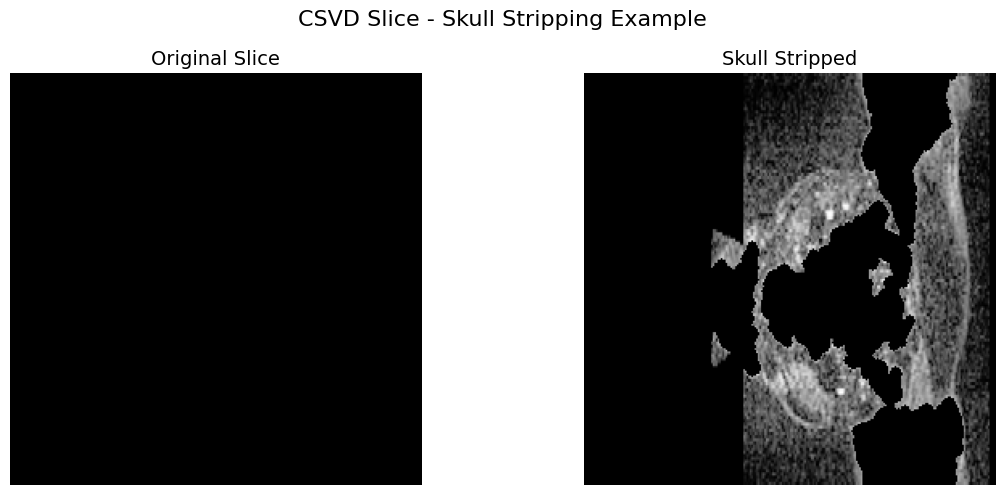

In [8]:
#Run on CSVD training example
show_example_skull_strip(csvd_train_slices, title="CSVD Slice - Skull Stripping Example")

Skull-stripped 1 slices.


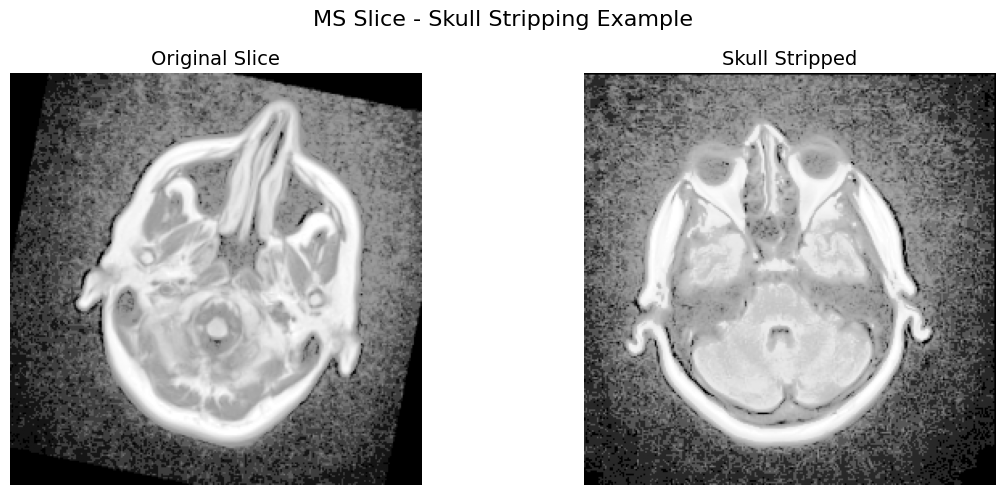

In [9]:
#Run on MS training example
show_example_skull_strip(ms_slices, title="MS Slice - Skull Stripping Example")

<h1>STEP-3: Extract HOG + GLCM Features from Each Slice</h1>

In [10]:
from skimage.feature import hog, graycomatrix, graycoprops
from tqdm import tqdm

def extract_features(slices, hog_orientations=8, hog_pix_cell=(16, 16), hog_block=(1, 1)):
    features = []

    for idx, slice_img in enumerate(tqdm(slices, desc="Extracting Features")):
        try:
            # Normalize to 0–255 and convert to uint8
            slice_img = np.clip(slice_img * 255, 0, 255).astype(np.uint8)

            # --- HOG Features ---
            hog_feat = hog(
                slice_img,
                orientations=hog_orientations,
                pixels_per_cell=hog_pix_cell,
                cells_per_block=hog_block,
                block_norm='L2-Hys',
                visualize=False,
                feature_vector=True
            )

            # GLCM Features 
            glcm = graycomatrix(slice_img, distances=[1], angles=[0],
                                levels=256, symmetric=True, normed=True)

            glcm_features = [
                graycoprops(glcm, prop)[0, 0]
                for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']
            ]

            # HOG + GLCM
            combined = np.hstack((hog_feat, glcm_features)).astype(np.float32)
            features.append(combined)

            if idx % 100 == 0:
                gc.collect()

        except Exception as e:
            print(f"Slice {idx} failed: {e}")
            continue

    return np.array(features, dtype=np.float32)


In [11]:
print("Extracting features for CSVD train set...")
csvd_train_features = extract_features(csvd_train_skull)

print("Feature extraction complete!")
print(f"CSVD Train: {csvd_train_features.shape}")

Extracting features for CSVD train set...


Extracting Features: 100%|█████████████████████████████████████████████████████████| 8820/8820 [01:41<00:00, 86.86it/s]

Feature extraction complete!
CSVD Train: (8820, 2053)


In [12]:
print("Extracting features for MS set...")
ms_features = extract_features(ms_skull)

print("Feature extraction complete!")
print(f"MS:         {ms_features.shape}")

Extracting features for MS set...


Extracting Features: 100%|█████████████████████████████████████████████████████████| 8746/8746 [01:33<00:00, 93.93it/s]

Feature extraction complete!
MS:         (8746, 2053)


<h1>Step 4: Lesion Detection Using Thresholding + Morphology</h1>

In [13]:
from skimage import morphology, measure

# Detect lesions in a single preprocessed slice
def detect_lesions(slice_img, min_area=20):
    try:
        # Normalize and convert to 8-bit
        img_uint8 = np.clip(slice_img * 255, 0, 255).astype(np.uint8)

        # Adaptive Thresholding
        thresh = cv2.adaptiveThreshold(
            img_uint8,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            blockSize=11,
            C=2
        )

        # Morphological Closing
        closed = morphology.binary_closing(thresh.astype(bool), morphology.disk(2))

        # Remove small objects
        cleaned = morphology.remove_small_objects(closed, min_size=min_area)

        # Label connected components
        labeled = measure.label(cleaned)
        mask = (labeled > 0).astype(np.uint8)

        return mask

    except Exception as e:
        print(f"Lesion detection failed: {e}")
        return np.zeros_like(slice_img, dtype=np.uint8)

# Batch lesion mask generation
def detect_lesions_batch(slices, verbose=True):
    lesion_masks = []
    for idx, slice_img in enumerate(slices):
        mask = detect_lesions(slice_img)
        lesion_masks.append(mask)

        if verbose and idx % 100 == 0:
            print(f"=>Processed {idx+1}/{len(slices)} slices...")
            gc.collect()

    return lesion_masks

#visualization of detection
def show_lesion_detection(slice_img, title="Lesion Detection Example"):
    lesion_mask = detect_lesions(slice_img)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(slice_img, cmap='gray')
    plt.title("Input Slice", fontsize=14)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(slice_img, cmap='gray')
    plt.imshow(lesion_mask, cmap='jet', alpha=0.4)
    plt.title("Lesion Mask", fontsize=14)
    plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


In [14]:
print("Detecting lesions in CSVD slices...")
csvd_lesion_masks = detect_lesions_batch(csvd_train_skull)

print("Lesion detection completed for both datasets!")

Detecting lesions in CSVD slices...
=>Processed 1/8820 slices...
=>Processed 101/8820 slices...
=>Processed 201/8820 slices...
=>Processed 301/8820 slices...
=>Processed 401/8820 slices...
=>Processed 501/8820 slices...
=>Processed 601/8820 slices...
=>Processed 701/8820 slices...
=>Processed 801/8820 slices...
=>Processed 901/8820 slices...
=>Processed 1001/8820 slices...
=>Processed 1101/8820 slices...
=>Processed 1201/8820 slices...
=>Processed 1301/8820 slices...
=>Processed 1401/8820 slices...
=>Processed 1501/8820 slices...
=>Processed 1601/8820 slices...
=>Processed 1701/8820 slices...
=>Processed 1801/8820 slices...
=>Processed 1901/8820 slices...
=>Processed 2001/8820 slices...
=>Processed 2101/8820 slices...
=>Processed 2201/8820 slices...
=>Processed 2301/8820 slices...
=>Processed 2401/8820 slices...
=>Processed 2501/8820 slices...
=>Processed 2601/8820 slices...
=>Processed 2701/8820 slices...
=>Processed 2801/8820 slices...
=>Processed 2901/8820 slices...
=>Processed 3001

In [15]:
print("Detecting lesions in MS slices...")
ms_lesion_masks = detect_lesions_batch(ms_skull)

print("Lesion detection completed for both datasets!")

Detecting lesions in MS slices...
=>Processed 1/8746 slices...
=>Processed 101/8746 slices...
=>Processed 201/8746 slices...
=>Processed 301/8746 slices...
=>Processed 401/8746 slices...
=>Processed 501/8746 slices...
=>Processed 601/8746 slices...
=>Processed 701/8746 slices...
=>Processed 801/8746 slices...
=>Processed 901/8746 slices...
=>Processed 1001/8746 slices...
=>Processed 1101/8746 slices...
=>Processed 1201/8746 slices...
=>Processed 1301/8746 slices...
=>Processed 1401/8746 slices...
=>Processed 1501/8746 slices...
=>Processed 1601/8746 slices...
=>Processed 1701/8746 slices...
=>Processed 1801/8746 slices...
=>Processed 1901/8746 slices...
=>Processed 2001/8746 slices...
=>Processed 2101/8746 slices...
=>Processed 2201/8746 slices...
=>Processed 2301/8746 slices...
=>Processed 2401/8746 slices...
=>Processed 2501/8746 slices...
=>Processed 2601/8746 slices...
=>Processed 2701/8746 slices...
=>Processed 2801/8746 slices...
=>Processed 2901/8746 slices...
=>Processed 3001/8

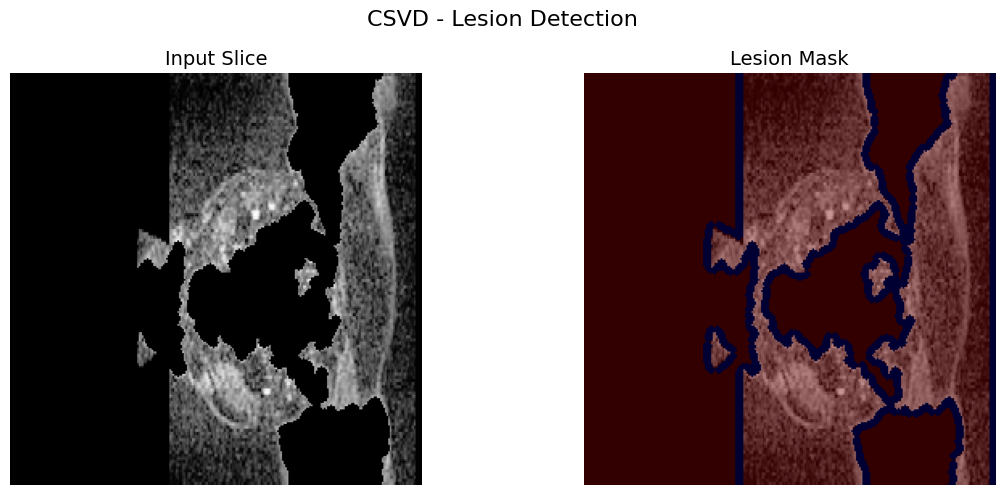

In [16]:
#Preview CSVD lesion detection
show_lesion_detection(csvd_train_skull[5], title="CSVD - Lesion Detection")

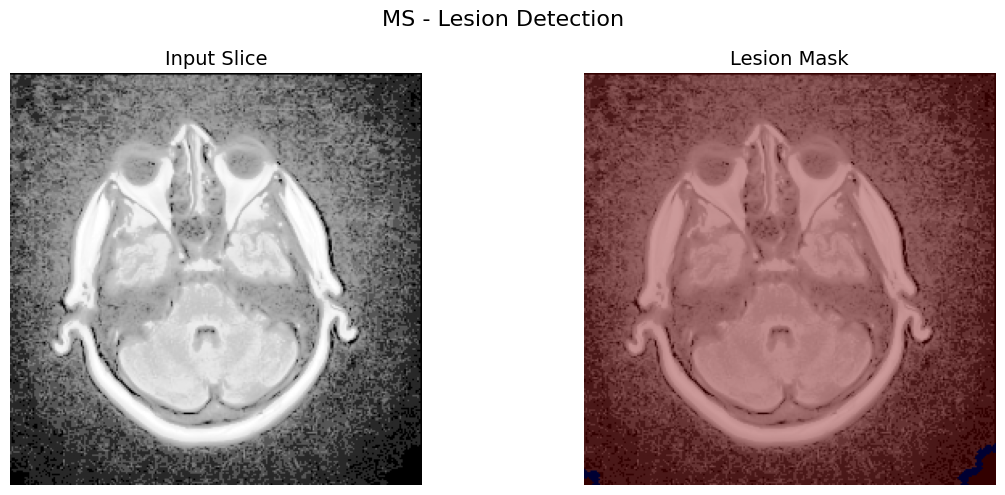

In [17]:
#Preview MS lesion detection
show_lesion_detection(ms_skull[5], title="MS - Lesion Detection")

<h1>Step 5: Train the Model (Only Training)</h1>

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# Labeling 0 for CSVD, 1 for MS
X = np.vstack([csvd_train_features, ms_features])
y = np.hstack([
    np.zeros(len(csvd_train_features)),  # CSVD label = 0
    np.ones(len(ms_features))            # MS label = 1
])

print(f"Combined dataset shape: {X.shape}, Labels: {y.shape}")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}")

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Save model
joblib.dump(clf, "trained_model_RF.pkl")
print("Model training complete. Model saved as 'trained_model_RF.pkl'")


Combined dataset shape: (17566, 2053), Labels: (17566,)
Train: (14052, 2053), Val: (3514, 2053)
Model training complete. Model saved as 'trained_model_RF.pkl'


<h1>Step 6 – Load and Predict on External Test Files</h1>

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Test data paths
ms_test_path = r"E:\CV_Project\MS\test"

# Load MS test data
print("Processing MS Test Data...")

ms_test_slices = load_flair_slices(ms_test_path)

ms_test_skull = resize_and_skull_strip(ms_test_slices)

ms_test_features = extract_features(ms_test_skull)

print(f"MS test features shape: {ms_test_features.shape}")

Processing MS Test Data...
Skull-stripped 18944 slices.


Extracting Features: 100%|███████████████████████████████████████████████████████| 18944/18944 [04:19<00:00, 72.86it/s]


MS test features shape: (18944, 2053)


In [20]:
from concurrent.futures import ThreadPoolExecutor

def find_flair_files(directory, flair_keywords=None):
    if flair_keywords is None:
        flair_keywords = ['flair']
    return [
        os.path.join(root, file)
        for root, _, files in os.walk(directory)
        for file in files
        if file.lower().endswith(('.nii', '.nii.gz')) and any(k in file.lower() for k in flair_keywords)
    ]

def load_slices_from_file(path, max_slices_per_volume=None):
    try:
        img = nib.load(path)
        data = np.asanyarray(img.dataobj)  # ensures full loading
        num_slices = min(data.shape[2], max_slices_per_volume) if max_slices_per_volume else data.shape[2]
        return [data[:, :, i] for i in range(num_slices)]
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return []

def load_flair_slices_fast(directory, flair_keywords=None, verbose=True, max_slices_per_volume=None, num_workers=4):
    if verbose:
        print(f"Searching in: {directory}")

    flair_files = find_flair_files(directory, flair_keywords)
    if verbose:
        print(f"Found {len(flair_files)} FLAIR files.")

    slices = []
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = [executor.submit(load_slices_from_file, path, max_slices_per_volume) for path in flair_files]
        for f in futures:
            slices.extend(f.result())

    if verbose:
        print(f"Loaded {len(slices)} total slices.")
    return slices


In [21]:
csvd_test_path = r"E:\CV_Project\CSVD\test"

# Load CSVD test data
print("\nProcessing CSVD Test Data...")

csvd_test_slices = load_flair_slices(csvd_test_path)

csvd_test_skull = resize_and_skull_strip(csvd_test_slices)

csvd_test_features = extract_features(csvd_test_skull)

print(f"CSVD test features shape: {csvd_test_features.shape}")


Processing CSVD Test Data...
Skull-stripped 18810 slices.


Extracting Features: 100%|███████████████████████████████████████████████████████| 18810/18810 [06:21<00:00, 49.30it/s]


CSVD test features shape: (18810, 2053)


In [22]:
X_test = np.vstack([ms_test_features, csvd_test_features])
y_test = np.array([1]*len(ms_test_features) + [0]*len(csvd_test_features))  # 1=MS, 0=CSVD

model = joblib.load("trained_model_RF.pkl") 

# Predict and evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy on test set: {acc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy on test set: 0.8641

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.77      0.85     18810
           1       0.81      0.96      0.88     18944

    accuracy                           0.86     37754
   macro avg       0.88      0.86      0.86     37754
weighted avg       0.88      0.86      0.86     37754

Confusion Matrix:
 [[14413  4397]
 [  732 18212]]


<h1>Step 7 : Evaluation visualization and enhancements</h1>

<ul>
    <h3>Plot Confusion Matrix</h3>
</ul>

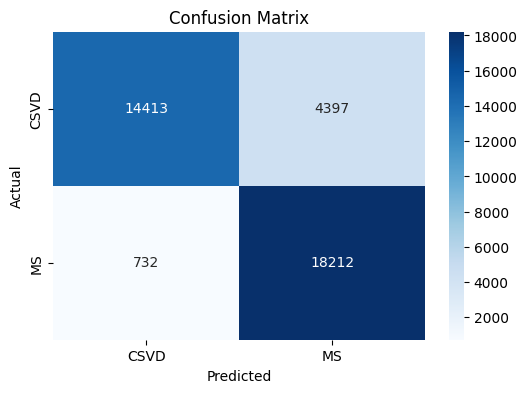

In [23]:
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, class_names=['CSVD', 'MS']):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Call it after prediction
plot_confusion_matrix(y_test, y_pred)


<ul>
    <h3>ROC Curve & AUC</h3>
</ul>

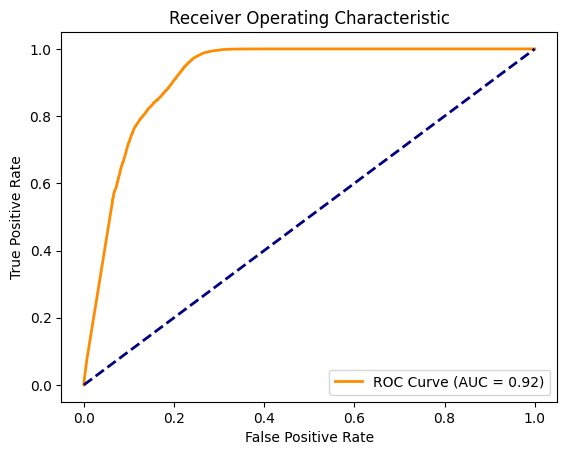

In [24]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(y_true, y_pred_proba):
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title("Receiver Operating Characteristic")
    plt.legend(loc="lower right")
    plt.show()

y_pred_proba = model.predict_proba(X_test)[:, 1]
plot_roc_curve(y_test, y_pred_proba)


In [25]:
import pandas as pd

#Convert classification report to DataFrame and round to 2 decimals
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df = report_df.round(2)
print("Classification Report (DataFrame format):")
display(report_df)

#Convert confusion matrix to DataFrame
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=["Actual CSVD (0)", "Actual MS (1)"], 
                     columns=["Predicted CSVD (0)", "Predicted MS (1)"])
print("Confusion Matrix (DataFrame format):")
display(cm_df)


Classification Report (DataFrame format):


,precision,recall,f1-score,support
0,0.95,0.77,0.85,18810.00
1,0.81,0.96,0.88,18944.00
accuracy,0.86,0.86,0.86,0.86
macro avg,0.88,0.86,0.86,37754.00
weighted avg,0.88,0.86,0.86,37754.00


Confusion Matrix (DataFrame format):


,Predicted CSVD (0),Predicted MS (1)
Actual CSVD (0),14413,4397
Actual MS (1),732,18212


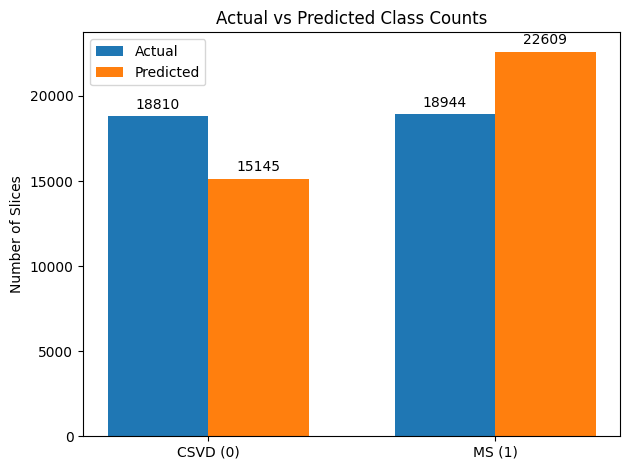

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Convert to numpy arrays if not already
y_test = np.array(y_test)
y_pred = np.array(y_pred)

# Count actual and predicted values
actual_counts = Counter(y_test)
pred_counts = Counter(y_pred)

labels = ['CSVD (0)', 'MS (1)']
x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, [actual_counts[0], actual_counts[1]], width, label='Actual')
bars2 = ax.bar(x + width/2, [pred_counts[0], pred_counts[1]], width, label='Predicted')

# Add labels and title
ax.set_ylabel('Number of Slices')
ax.set_title('Actual vs Predicted Class Counts')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add bar labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()


Enter the full path to the FLAIR .nii file:  E:\CV_Project\MS\Training\Patient-1\1-Flair.nii


Skull-stripped 23 slices.


Extracting Features: 100%|█████████████████████████████████████████████████████████████| 23/23 [00:00<00:00, 35.36it/s]



🧠 Prediction: MS (Multiple Sclerosis)
🔍 Confidence Score: 96.61%


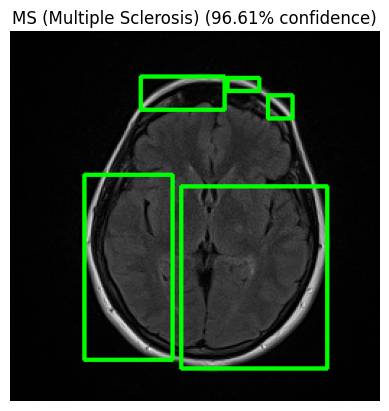

In [35]:
import os
import numpy as np
import nibabel as nib
import cv2
import gc
import joblib


model = joblib.load("trained_model_RF.pkl")  # Make sure this is the correct path

# Ask for image path
input_path = input("Enter the full path to the FLAIR .nii file: ")

if not os.path.exists(input_path):
    print("File not found. Please check the path.")
else:
    # Load the NIfTI image
    img = nib.load(input_path)
    data = img.get_fdata()

    # Convert to individual slices
    slices = [data[:, :, i] for i in range(data.shape[2])]

    # Preprocess slices (skull strip + resize)
    processed = resize_and_skull_strip(slices)  # You should have this function defined

    # Extract features from slices
    features = extract_features(processed)  # You should have this function defined

    # Predict probabilities and class
    probs = model.predict_proba(features)
    predictions = np.argmax(probs, axis=1)

    # Final prediction: majority vote
    final_prediction = np.bincount(predictions).argmax()

    # Confidence: average probability of the majority class
    confidence = np.mean(probs[:, final_prediction]) * 100

    # Label and box color based on prediction
    if final_prediction == 1:
        label = "MS (Multiple Sclerosis)"
        box_color = (0, 255, 0)  # Green
    elif final_prediction == 0:
        label = "CSVD (Small Vessel Disease)"
        box_color = (255, 0, 0)  # Red
    else:
        label = "Healthy Brain"
        box_color = (255, 255, 255)  # White

    print(f"\n🧠 Prediction: {label}")
    print(f"🔍 Confidence Score: {confidence:.2f}%")

    # Visualize the middle slice
    mid_slice_idx = len(slices) // 2
    img_slice = slices[mid_slice_idx]

    # Normalize to 8-bit
    img_normalized = cv2.normalize(img_slice, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Blur to reduce noise
    img_blur = cv2.GaussianBlur(img_normalized, (5, 5), 0)

    # Thresholding
    _, thresh = cv2.threshold(img_blur, 90, 255, cv2.THRESH_BINARY)

    # Morphological clean-up
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # Contour detection
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Default: no bounding boxes if healthy
    draw_boxes = True

    if len(contours) == 0 or max(cv2.contourArea(cnt) for cnt in contours) < 200:
        print("\nNo significant lesions detected — The brain appears healthy.")
        label = "No Disease Found"
        box_color = (255, 255, 255)
        draw_boxes = False

    # Prepare image for visualization
    img_bgr = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2BGR)

    # Draw boxes if any significant region exists
    if draw_boxes:
        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)
            if w * h > 100:  # Ignore very small boxes
                cv2.rectangle(img_bgr, (x, y), (x + w, y + h), box_color, 2)

    # Display image with prediction
    plt.imshow(img_bgr)
    plt.title(f"{label} ({confidence:.2f}% confidence)")
    plt.axis('off')
    plt.show()